# Learning when silence has no click: Online SDFT

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lin826/Online-SFT-Demo/blob/main/online_sdft_bandit_demo.ipynb)

Picture one notification arriving **now**. The model knows its context but not the user's reaction. It must choose `INTERRUPT`, `LATER`, or `ARCHIVE`; that choice determines which outcome can become observable. This notebook follows that one-way causal sequence as a **contextual bandit**, not a labeled batch-learning problem.

> **Mental model:** every event is first a live test decision. Only after the action is committed can its factual outcome become evidence for later decisions. There is no answer key before acting and no do-over after learning.

In [1]:
from pathlib import Path
import csv, json, os, subprocess
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'bandit_experiment.py').exists() and Path('/content').exists():
    repo = Path('/content/Online-SFT-Demo')
    if not repo.exists():
        subprocess.run(['git', 'clone', 'https://github.com/lin826/Online-SFT-Demo.git', str(repo)], check=True)
    os.chdir(repo)
    ROOT = Path.cwd()
if not (ROOT / 'bandit_experiment.py').exists():
    raise RuntimeError('Run this notebook from the repository root or open it in Colab.')
OUT = ROOT / 'outputs' / 'bandit'

## The contextual-bandit contract

At round `t`, the student sees context `xₜ` and generates its own action `aₜ ~ πₜ(·|xₜ)`. The action is **scored before feedback**, then only that action is executed. The environment returns one factual observation `zₜ ~ P(·|xₜ,aₜ)`. A teacher may interpret `(xₜ,aₜ,zₜ)`, and a tiny update may improve `πₜ₊₁`—but it cannot change the decision already counted at `t`.

| Moment | Available to the learner | Sealed away |
| --- | --- | --- |
| Choose `aₜ` | current `xₜ`, current policy, past factual records | current feedback, future events, oracle action, ground-truth demonstration |
| Observe | outcome caused by the selected action | outcomes of both unchosen actions |
| Update for `t+1` | teacher distribution from the factual record, small replay batch | scoring oracle, fabricated counterfactual reactions, retroactive correction |

The simulator has hidden utilities so the **researcher** can compute accuracy and regret. That scoring oracle is an evaluation instrument, never a training label and never an input to the teacher.

### Why this is realistic—and unlike batch learning

If the agent chooses **ARCHIVE**, no push or digest exists. The user can later open the inbox organically, or we observe nothing; a notification click is impossible. `NO_OBSERVATION` remains ambiguous rather than being turned into a convenient negative label.

| Batch supervised learning | This online contextual bandit |
| --- | --- |
| labels are available before optimization | feedback arrives only after the action |
| examples can be shuffled for many epochs | one drifting stream arrives in order |
| evaluation happens after training on a held-out split | every action is charged before its update |
| early training errors disappear from test metrics | early errors remain in online accuracy and cumulative regret |

There is no train/test split because performance **while learning** is the target. Each round is predict → score → act → observe → learn for the next round.

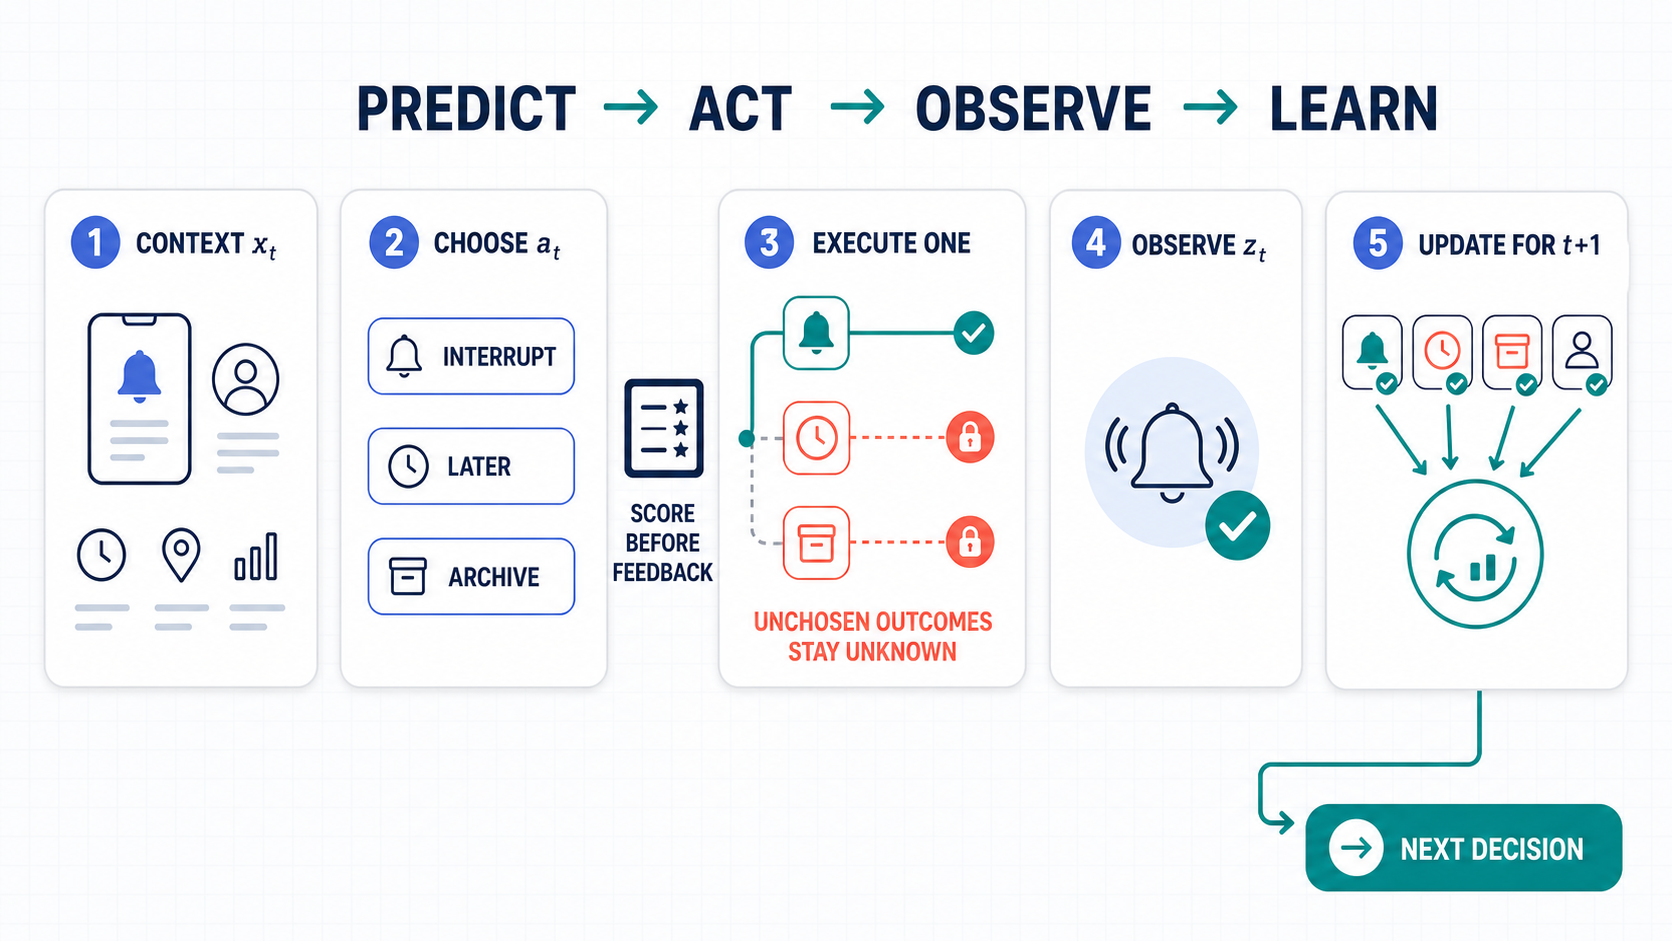

In [2]:
display(Image(filename=str(ROOT / 'figures' / 'contextual_bandit_loop.png'), width=1200))

## Reproduce the experiment

The checked-in outputs use 20 seeds. Set `RUN_EXPERIMENT=True` to regenerate all 24,000 decisions and figures.

In [3]:
RUN_EXPERIMENT = False
if RUN_EXPERIMENT:
    from bandit_experiment import main
    main(seeds=20)

## Five methods, one causal learning signal

- **Base:** frozen generic policy.
- **ICL:** recent hard teacher rollouts in context.
- **RAG:** hard rollouts from similar past contexts.
- **Online-SFT:** after factual feedback, one sampled teacher rollout becomes a hard target.
- **Online-SDFT:** after factual feedback, learns the complete teacher distribution in a batch of at most four records.

The student always acts from `xₜ` without privileged `zₜ`. The teacher speaks only after execution and is not given the ground-truth action. No method learns from the evaluation oracle.

In [4]:
summary = json.loads((OUT / 'summary.json').read_text())
methods = summary['config']['methods']
print(f"{summary['config']['seeds']} seeds × {summary['config']['stream_length']} decisions")
print(f"{'Method':<14} {'Accuracy':>12} {'95% CI':>10} {'Regret':>12} {'95% CI':>10}")
for method in methods:
    row = summary['summary'][method]
    a, r = row['online_accuracy'], row['cum_regret']
    print(f"{method:<14} {100*a['mean']:>11.2f}% {100*a['ci95']:>9.2f} {r['mean']:>12.2f} {r['ci95']:>10.2f}")

20 seeds × 240 decisions
Method             Accuracy     95% CI       Regret     95% CI
Base                 52.17%      1.23        71.17       2.93
ICL                  45.75%      1.05        78.38       3.39
RAG                  53.15%      1.62        56.60       4.39
Online-SFT           61.79%      2.51        40.17       4.51
Online-SDFT          74.77%      1.24        18.65       1.28


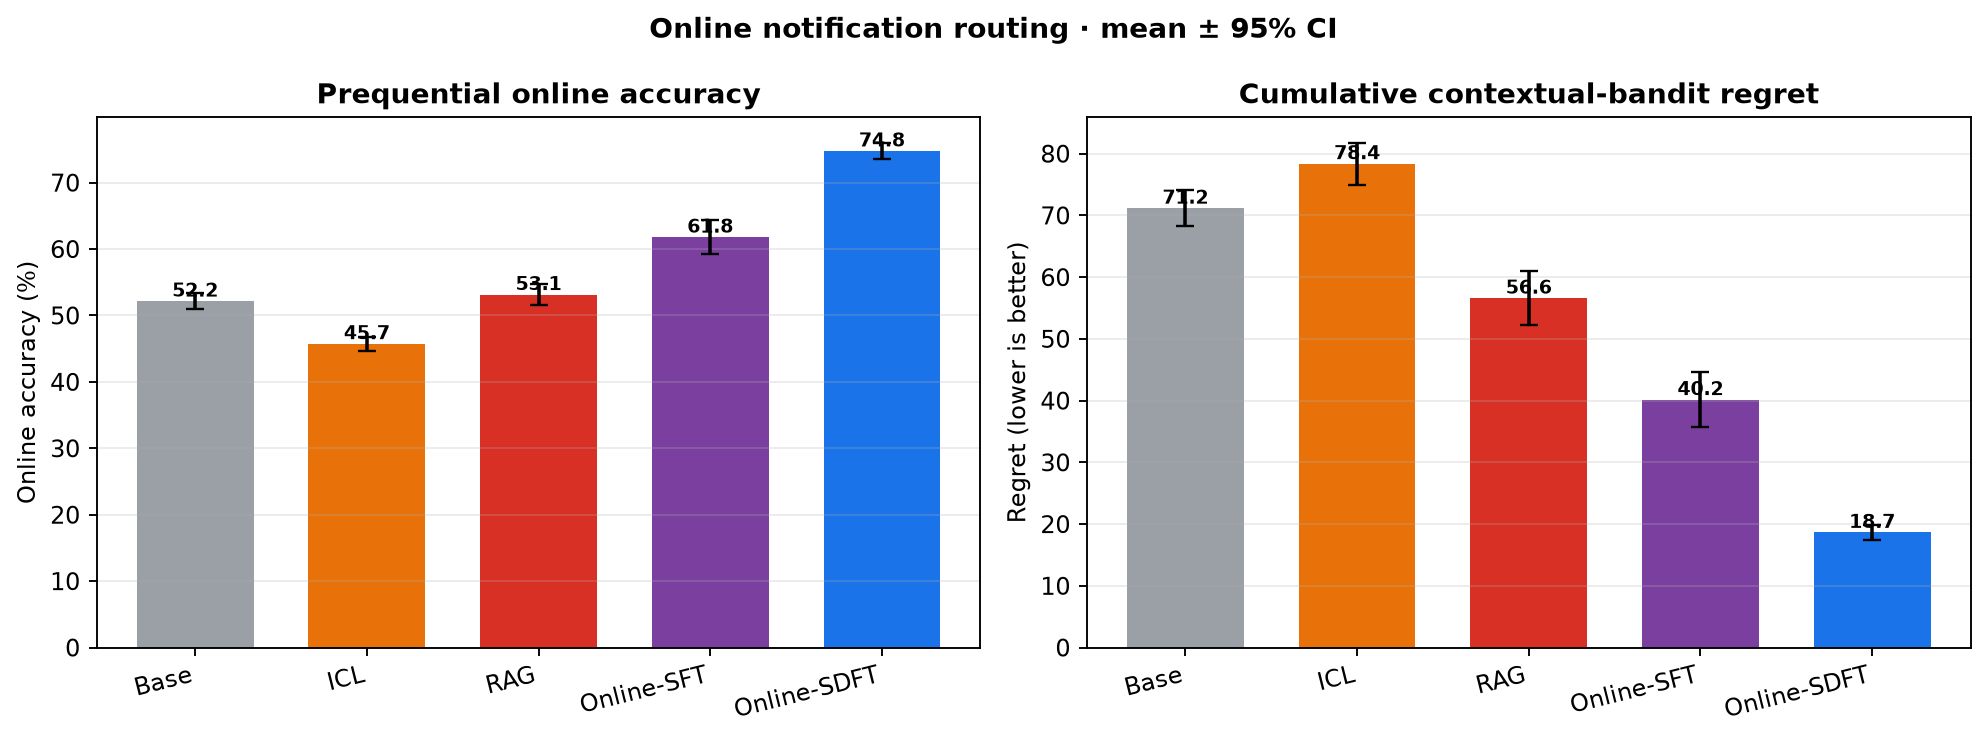

In [5]:
display(Image(filename=str(ROOT / 'figures' / 'bandit_accuracy.png'), width=950))

## Watch adaptation and regret accumulate

Dashed boundaries mark the weekday → on-call → off-hours shifts. Shaded regions are 95% confidence intervals.

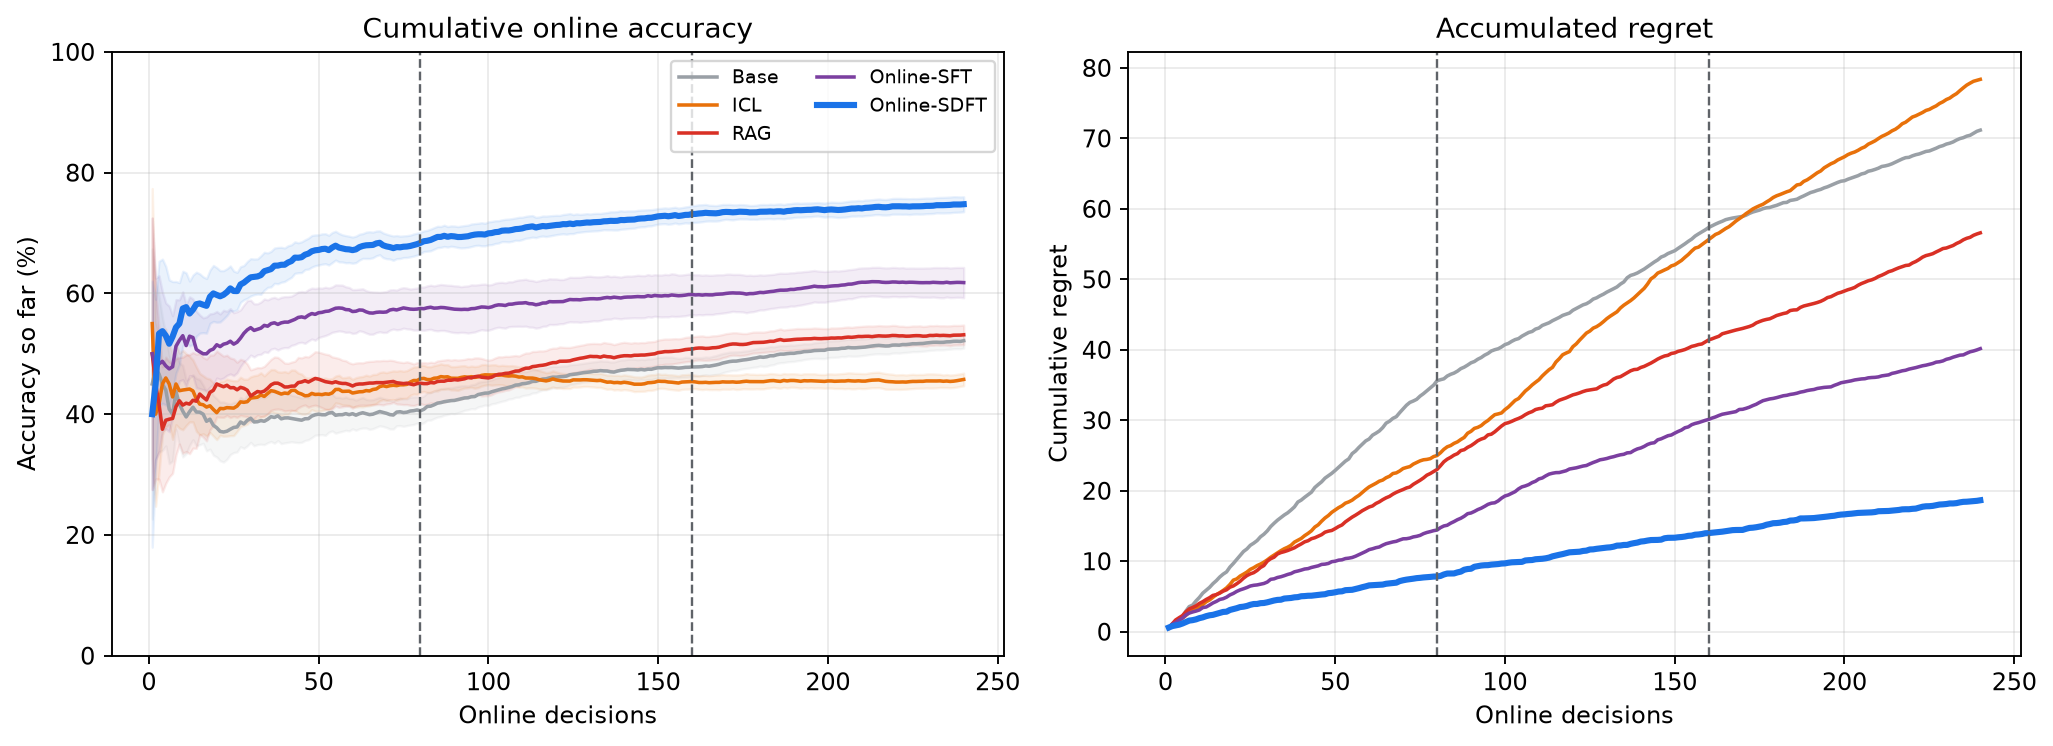

In [6]:
display(Image(filename=str(ROOT / 'figures' / 'bandit_learning_curves.png'), width=1000))

## Audit the counterfactual boundary

The raw rollout log makes the information boundary auditable. Archived decisions can yield only `ORGANIC_INBOX_OPEN` or `NO_OBSERVATION`; they never generate push or digest clicks. Oracle fields are explicitly marked `scoring_only`, and update APIs do not accept them.

In [7]:
rollouts = [json.loads(line) for line in (OUT / 'rollouts.jsonl').open()]
archived = [r for r in rollouts if r['action'] == 'ARCHIVE']
archive_outcomes = Counter(r['feedback']['outcome'] for r in archived)
display(Markdown(f'**{len(archived):,} archived decisions:** `{dict(archive_outcomes)}`'))
assert set(archive_outcomes) <= {'ORGANIC_INBOX_OPEN', 'NO_OBSERVATION'}

**5,142 archived decisions:** `{'NO_OBSERVATION': 4536, 'ORGANIC_INBOX_OPEN': 606}`

## Where soft rollouts help

These examples occur after at least one complete online regime. SDFT is correct while every comparison method chooses another route. The outcome shown for each method is factual for its own chosen action.

In [8]:
examples = json.loads((OUT / 'qualitative_examples.json').read_text())
for ex in examples[:4]:
    display(Markdown(f"### Step {ex['t']} · {ex['regime']} · {ex['category']}  \nScoring-best route: **{ex['oracle_action_scoring_only']}**"))
    for method, row in ex['methods'].items():
        marker = '✅' if row['action'] == ex['oracle_action_scoring_only'] else '·'
        print(f"{marker} {method:<13} {row['action']:<10} → {row['feedback']['outcome']}")

### Step 87 · on-call · receipt  
Scoring-best route: **ARCHIVE**

· Base          INTERRUPT  → DISMISSED_PUSH
· ICL           LATER      → OPENED_DIGEST
· RAG           INTERRUPT  → DISMISSED_PUSH
· Online-SFT    LATER      → IGNORED_DIGEST
✅ Online-SDFT   ARCHIVE    → NO_OBSERVATION


### Step 96 · on-call · receipt  
Scoring-best route: **ARCHIVE**

· Base          INTERRUPT  → OPENED_PUSH
· ICL           INTERRUPT  → OPENED_PUSH
· RAG           LATER      → IGNORED_DIGEST
· Online-SFT    LATER      → IGNORED_DIGEST
✅ Online-SDFT   ARCHIVE    → NO_OBSERVATION


### Step 150 · on-call · receipt  
Scoring-best route: **ARCHIVE**

· Base          INTERRUPT  → IGNORED_PUSH
· ICL           INTERRUPT  → IGNORED_PUSH
· RAG           LATER      → OPENED_DIGEST
· Online-SFT    LATER      → IGNORED_DIGEST
✅ Online-SDFT   ARCHIVE    → NO_OBSERVATION


### Step 162 · off-hours · social  
Scoring-best route: **LATER**

· Base          INTERRUPT  → OPENED_PUSH
· ICL           INTERRUPT  → DISMISSED_PUSH
· RAG           INTERRUPT  → DISMISSED_PUSH
· Online-SFT    INTERRUPT  → OPENED_PUSH
✅ Online-SDFT   LATER      → IGNORED_DIGEST


## Takeaway

This is deliberately a harder and more realistic objective than held-out accuracy after batch training: each method pays for every cold-start, exploration, and adaptation mistake at the moment it happens. SFT receives one noisy sampled action from the post-decision teacher; SDFT receives the teacher's relative preference over all three actions. On the same prequential stream, retaining that uncertainty improves sample efficiency: **74.8% vs 61.8% online accuracy**, with **18.7 vs 40.2** cumulative regret.